In [1]:
import pricing_driven_service_allocation as pdsa

# URLS
PRIME_INSTANCE_URL = "http://localhost:3000/api/v1/"
# Paths
TOPOLOGIES_DIR = "synthetic-dataset/synthetic-topologies"
RESULTS_DIR = "results"
DEVICES_EUA_DATASET_PATH = "eua-dataset/edge-servers/site.csv"
CLIENTS_EUA_DATASET_PATH = "eua-dataset/users/users-aus.csv"
EXPERIMENT_CONFIGURATION_PATH = "experiments/experiment_test.yml"
# Scenario containers
topologies = {}
demands = {}
filters = {}
results = {}
# Configuration
SEED = 42
UNLIMITED_VALUE = 100000000
VENDORS_TO_CONSIDER = ["Telstra", "Optus", "Vodafone", "Telecom", "Macquarie"]
OFFER_CONFIGURATION = {
    "global": {
        "group_percentages": {1: 40, 2: 30, 3: 30},
        "group_ranges": {1: (0, 12.5), 2: (12.5, 50), 3: (50, 100)},
    },
    "attributes": {
        "available_ram_gb": {
            "min": 1,
            "max": 128,
            "default_price": 0.5,
            "price_by_provider_group": {
                "OPTUS": {1: 1, 2: 0.15, 3: 0.005},
                "TELSTRA": {1: 1.3, 2: 0.12, 3: 0.003},
                "VODAFONE": {1: 1.5, 2: 0.18, 3: 0.001},
                "MACQUARIE": {1: 0.2, 2: 0.17, 3: 0.008},
                "TELECOM": {1: 0.7, 2: 0.14, 3: 0.004},
            },
            "local_distribution": {1: [(70, 0, 25), (30, 25, 100)]},
        },
        "available_storage_gb": {
            "min": 1,
            "max": 2000,  # gigabytes; adjust if you want very large storage nodes
            "default_price": 0.2,
            "price_by_provider_group": {
                "OPTUS": {1: 0.90, 2: 0.25, 3: 0.08},
                "TELSTRA": {1: 1.10, 2: 0.30, 3: 0.10},
                "VODAFONE": {1: 1.25, 2: 0.35, 3: 0.05},
                "MACQUARIE": {1: 0.50, 2: 0.20, 3: 0.09},
                "TELECOM": {1: 0.85, 2: 0.28, 3: 0.07},
            },
            "local_distribution": {
                # Conserva tu intención: muchos dispositivos con poco almacenamiento y unos pocos con más
                1: [(70, 0, 2), (30, 2, 25)]
            },
        },
        "available_cpu_cores": {
            "min": 1,
            "max": 64,
            "default_price": 15,
        },
        # Unidades equivalentes, coherentes con gpu_equivalent_units en demanda
        "available_gpu_units": {
            "min": 0,
            "max": 8,
            "default_price": 120,
            "price_by_provider_group": {
                "TELSTRA": {2: 130, 3: 150},
                "OPTUS": {3: 140},
            },
            "local_distribution": {
                1: [(85, 0, 25), (15, 25, 50)],
                2: [(60, 0, 50), (40, 50, 100)],
                3: [(30, 0, 50), (70, 50, 100)],
            },
        },
        "available_tpu_units": {
            "min": 0,
            "max": 4,
            "default_price": 200,
            "price_by_provider_group": {
                "TELSTRA": {3: 240},
                "OPTUS": {2: 210},
            },
            "local_distribution": {
                1: [(90, 0, 25), (10, 25, 50)],
                2: [(70, 0, 50), (30, 50, 100)],
                3: [(40, 0, 50), (60, 50, 100)],
            },
        },
        # Opcional: si luego quieres que el algoritmo también restrinja por ancho de banda
        "available_network_in_mbps": {
            "min": 10,
            "max": 10000,
            "default_price": 0.01,
            "local_distribution": {
                1: [(80, 0, 20), (20, 20, 100)],
                2: [(60, 20, 60), (40, 60, 100)],
                3: [(20, 60, 100), (80, 80, 100)],
            },
        },
        "available_network_out_mbps": {
            "min": 10,
            "max": 10000,
            "default_price": 0.01,
            "local_distribution": {
                1: [(80, 0, 20), (20, 20, 100)],
                2: [(60, 20, 60), (40, 60, 100)],
                3: [(20, 60, 100), (80, 80, 100)],
            },
        },
    },
    "device_types_by_group": {
        1: {"CAMERA": 35, "SENSOR": 35, "NETWORK_NODE": 30},
        2: {"COMPUTER": 60, "NETWORK_NODE": 40},
        3: {"DATA_CENTER": 100},
    },
}
RESOURCES_TO_CONSIDER = [
    key for key in OFFER_CONFIGURATION["attributes"].keys() if "network" not in key
]

In [2]:
import yaml
import os

# Load the YAML file
with open(os.path.join(EXPERIMENT_CONFIGURATION_PATH), 'r') as file:
  config_data = yaml.safe_load(file)
  
for scenario_size in config_data['experiments'].keys():
    for app in config_data['experiments'][scenario_size].keys():
        topology_offer = config_data['experiments'][scenario_size][app]['offer']
        # Check that all providers in the topology offer are in the vendors to consider
        providers_in_offer = [p.lower() for p in topology_offer['providers'].keys()]
        vendors_lower = [v.lower() for v in VENDORS_TO_CONSIDER]

        if not all(provider in vendors_lower for provider in providers_in_offer):
          raise ValueError(f"Some providers in topology {scenario_size}/{app} offer are not in VENDORS_TO_CONSIDER."
                   f"Providers in offer: {providers_in_offer}, "
                   f"Vendors to consider: {vendors_lower}")

In [3]:
import os
import shutil

# Create all defined paths if they do not exist
paths_to_create = [
  TOPOLOGIES_DIR,
]

for path in paths_to_create:
  if path and not os.path.exists(path):
    os.makedirs(path, exist_ok=True)
    print(f"Created directory: {path}")
  elif path and os.path.exists(path):
    print(f"Directory already exists: {path}. Removing existing subfolders...")
    # Remove existing subfolders (including non-empty ones)
    for subfolder in os.listdir(path):
      subfolder_path = os.path.join(path, subfolder)
      if os.path.isdir(subfolder_path):
        shutil.rmtree(subfolder_path)
    print("Done!")
    

Directory already exists: synthetic-dataset/synthetic-topologies. Removing existing subfolders...
Done!


# 2. Filter EUA dataset

In this step, we will filter the EUA dataset to include only devices from which we can infer the vendor, usually throug their description. This is crucial for our analysis as it allows us to categorize devices and simulate exclusion and interoperability relationships among providers.

In addition, we will enrich the dataset with synthetic resources, unit prices, and device types. This enrichment is based on the OFFER_CONFIGURATION defined at the beginning of the notebook.

In [4]:
# Load dataset
devices_df = pdsa.dataset.load_devices_dataframe(DEVICES_EUA_DATASET_PATH)
# Filter devices from which vendor can be inferred
devices_df = pdsa.dataset.filter_devices_by_vendors(devices_df, VENDORS_TO_CONSIDER)
# Assign resources to devices based on the offer configuration
devices_df = pdsa.dataset.assign_device_resources(devices_df, OFFER_CONFIGURATION, SEED)

devices_df.head()

,latitude,longitude,elevation,provider,global_group,device_type,available_ram_gb,unit_price_available_ram_gb,available_storage_gb,unit_price_available_storage_gb,available_cpu_cores,unit_price_available_cpu_cores,available_gpu_units,unit_price_available_gpu_units,available_tpu_units,unit_price_available_tpu_units,available_network_in_mbps,unit_price_available_network_in_mbps,available_network_out_mbps,unit_price_available_network_out_mbps
device_id,,,,,,,,,,,,,,,,,,,,
10000002,-28.777660,114.634260,NaN,OPTUS,1,SENSOR,5,1.000,5,0.90,4,15.0,0,120.0,0,200.0,25,0.01,983,0.01
100001,-38.248652,144.605442,23.0,TELSTRA,1,NETWORK_NODE,12,1.300,9,1.10,6,15.0,0,120.0,0,200.0,130,0.01,239,0.01
10000114,-31.901910,152.533540,NaN,OPTUS,3,DATA_CENTER,95,0.005,1818,0.08,39,15.0,7,140.0,3,200.0,9296,0.01,9484,0.01
100002,-37.728550,145.222007,116.0,OPTUS,2,NETWORK_NODE,61,0.150,394,0.25,29,15.0,1,120.0,0,210.0,4437,0.01,2391,0.01
10000215,-32.981570,121.644400,NaN,TELSTRA,2,NETWORK_NODE,22,0.120,949,0.30,11,15.0,1,130.0,1,200.0,2270,0.01,2359,0.01


# 3. Topology Generation

In [5]:

for scenario_size in config_data['experiments'].keys():
    for app in config_data['experiments'][scenario_size].keys():
        topology_offer = config_data['experiments'][scenario_size][app]['offer']
        _, topology_id = pdsa.generators.topology(
                          lat = topology_offer['zone']['lat'],
                          long = topology_offer['zone']['long'],
                          center_elevation = topology_offer['zone'].get('elevation', 0),
                          rad=topology_offer['zone']['radius'],
                          devices_df=devices_df,
                          topologies_result_dir=TOPOLOGIES_DIR,
                          resources_to_consider=RESOURCES_TO_CONSIDER,
                          number_of_providers=len(topology_offer["providers"]),
                          allowed_groups=[1, 2, 3],
                          number_of_devices=topology_offer['max_devices'],
                          options={"seed": SEED, "logs": False}
                      )
        topologies[f"{scenario_size}_{app}"] = topology_id
        
print("---- Topologies generated ----\n")
for key, value in topologies.items():
  print(f"{key}: {value}")

---- Topologies generated ----

small_vr: 0f21b101-4041-4464-9c91-2c062f469146
small_robot: ba4e8c01-e61a-44bc-96ff-53fb6d45a1ec
small_lidar: ccef6412-67b1-46c4-ba71-5005f160d104
small_cctv: b9287d06-f9f6-4c22-aaf1-202df573485e
medium_vr: a9424ce5-0417-423e-8859-06a655dc53e8
medium_robot: cc61e0ce-5132-45d9-8cdf-2e7eca8006bf
medium_lidar: 1019c25e-0ce4-44b0-854e-1eb01e64af37
medium_cctv: 2630f389-5f78-4d1f-b3e6-f8ea94173a8d
large_vr: 6da97117-c5c0-4ad9-86cb-d99b29252670
large_robot: 01a8d932-f256-49e6-9c5f-da618da1e5fa
large_lidar: db02fcbf-480f-41a4-a5a0-651ab577e04f
large_cctv: 78a1d905-b3a2-4960-9ccf-7bff10ec512d


# 4. Problem instance generation

In [6]:
import os

if not os.path.exists("./iPricing/model"):
    os.makedirs("./iPricing/model")

!protoc --python_out=./iPricing/model ./iPricing/iPricing.proto
!mv ./iPricing/model/iPricing/iPricing_pb2.py ./iPricing/model/iPricing_pb2.py
!rm -rf ./iPricing/model/iPricing

In [7]:
import pandas as pd
from pricing_driven_service_allocation.generators.client_demand import AppType

app_mapping = {
  "vr": AppType.AR_VR,
  "cctv": AppType.VIDEO_PRIVACY,
  "lidar": AppType.LIDAR,
  "robot": AppType.ROBOT_IOT
}

In [8]:
from tqdm import tqdm
from iPricing.model.iPricing_pb2 import Pricing

for id, topology_id in tqdm(topologies.items(), desc="Generating instances"):
  print(id)
  scenario_size, app = id.split("_")
  topology_demand = config_data['experiments'][scenario_size][app]['demand']
  topology_request = config_data['experiments'][scenario_size][app]['request']
  
  users_demand = pdsa.generators.client_demand.calculate_resources(topology_demand['n_clients'], 
                                                                   app_mapping[app], 
                                                                   concurrency=topology_demand['concurrency'], 
                                                                   requests_per_second_per_active_client=topology_demand['requests_per_second_per_active_client'], 
                                                                   requests_per_second_std=topology_demand['requests_per_second_std'], 
                                                                   resources_to_consider=RESOURCES_TO_CONSIDER, 
                                                                   random_state=SEED)
  
  request = pdsa.generators.request(
      topology_demand=topology_demand,
      topology_request=topology_request,
      users_demand=users_demand,
      resources_to_consider=RESOURCES_TO_CONSIDER,
  )
  
  pricing_path = pdsa.generators.pricing_from_topology(
            topology_id=topology_id,
            topologies_result_dir=TOPOLOGIES_DIR,
            resources_to_consider=RESOURCES_TO_CONSIDER,
            compatible_provider_groups=pdsa.generators.compatible_provider_groups_from_offer(topology_offer),
            options={"logs": False}
          )
  
  pricing_obj = pdsa.utils.yaml_to_pricing_proto(
      os.path.join(TOPOLOGIES_DIR, topology_id, "pricing.yml"), 
      Pricing
  )
  
  problem_instance_pricing, filter_criteria = pdsa.generators.problem_instance(
                                                  instance_pricing=pricing_obj,
                                                  request=request,
                                                  topologies_result_dir=TOPOLOGIES_DIR,
                                                  unlimited_value=UNLIMITED_VALUE
                                              )
  
  pdsa.utils.pricing_proto_to_yaml(
    problem_instance_pricing, 
    os.path.join(TOPOLOGIES_DIR, topology_id, "problem_instance_pricing.yml"),
    options={"logs": False}
  )
  
  filters[id] = filter_criteria
  

Generating instances:   0%|          | 0/12 [00:00<?, ?it/s]

small_vr


Generating instances:   8%|▊         | 1/12 [00:00<00:03,  3.23it/s]

small_robot


Generating instances:  17%|█▋        | 2/12 [00:00<00:03,  3.29it/s]

...

Generating instances:  83%|████████▎ | 10/12 [00:15<00:05,  2.87s/it]

large_lidar


Generating instances:  92%|█████████▏| 11/12 [00:16<00:02,  2.17s/it]

large_cctv


Generating instances: 100%|██████████| 12/12 [00:20<00:00,  1.72s/it]


# 5. Pricing Optimization

In [9]:
print(filters["small_vr"])

{'maxPrice': 1000, 'maxSubscriptionSize': 4, 'usageLimits': {'available_ram_gb': 3, 'available_storage_gb': 3, 'available_cpu_cores': 1, 'available_gpu_units': 1, 'available_tpu_units': 0, 'distance': 99996250}, 'features': ['CAMERA', 'SENSOR', 'NETWORK_NODE', 'DATA_CENTER']}


In [10]:
import time
from tqdm import tqdm

if os.path.exists(os.path.join(RESULTS_DIR, "results.csv")):
    print(f"Results directory '{RESULTS_DIR}' already exists. Removing existing results...")
    shutil.rmtree(RESULTS_DIR)
    print("Done!")

for id in tqdm(list(topologies.keys()), desc="Optimizing topologies"):
  instance_path = os.path.join(TOPOLOGIES_DIR, topologies[id], "problem_instance_pricing.yml")
  
  filter = filters[id]
  
  start = time.time()
  result = pdsa.optimize(PRIME_INSTANCE_URL, instance_path, filter)
  elapsed_time = time.time() - start
  
  results[id] = {
    "result": result,
    "filter": filter,
    "time": elapsed_time
  }
  
  pdsa.dataset.save_results_to_csv(
    result_obj=results[id],
    scenario_id=id,
    RESULTS_DIR=RESULTS_DIR
  )
  
  

Results directory 'results' already exists. Removing existing results...
Done!


Optimizing topologies: 100%|██████████| 12/12 [02:36<00:00, 13.04s/it]


# 6. Display results

/var/folders/hn/690621xn78d0fvfsqqzlpy000000gn/T/ipykernel_7840/3461493773.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby(['size','app'])['time_seconds'].agg(['mean','std']).reset_index()


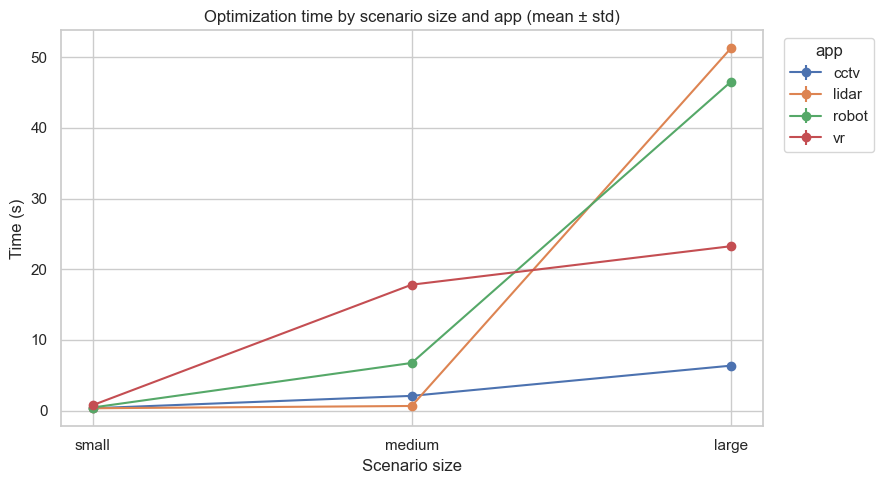

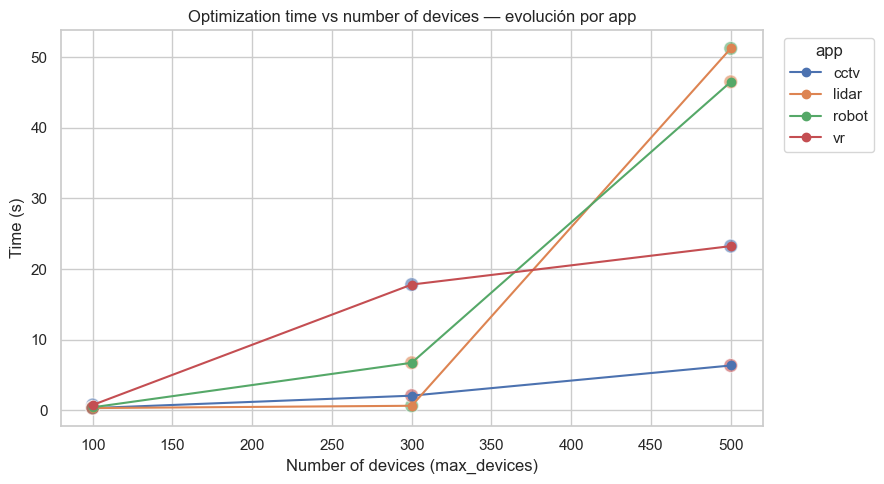

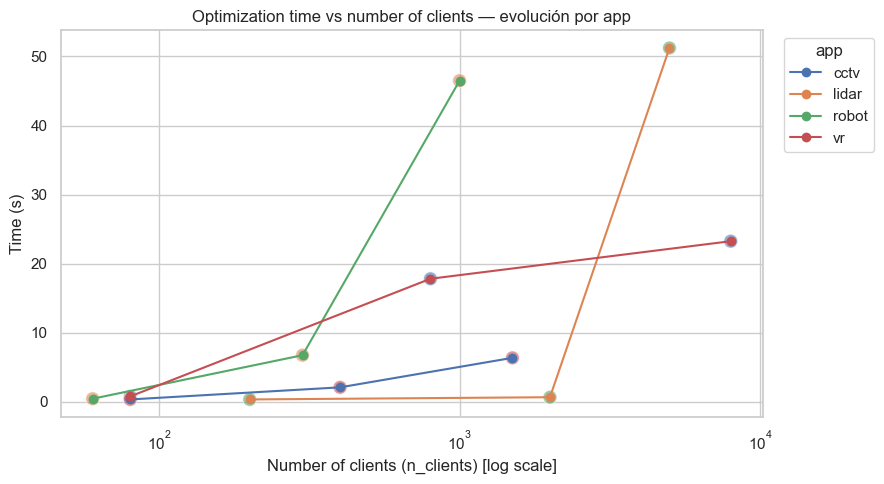

Saved figures in: results/figures


In [8]:
# 6. Display and save result figures (reduced to requested plots)
import pandas as pd
import os
import yaml
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set(style='whitegrid')

RESULTS_CSV = os.path.join(RESULTS_DIR, 'results.csv')
df = pd.read_csv(RESULTS_CSV)

# Extract size and app from scenario_id
def split_scenario(s):
    if pd.isna(s):
        return ('', '')
    parts = str(s).split('_')
    size = parts[0] if len(parts) > 0 else ''
    app = parts[1] if len(parts) > 1 else ''
    return (size, app)

df[['size','app']] = df['scenario_id'].apply(lambda s: pd.Series(split_scenario(s)))

# Ensure numeric time
df['time_seconds'] = pd.to_numeric(df['time_seconds'], errors='coerce')
df = df.dropna(subset=['time_seconds'])

# Define sensible ordering for sizes
preferred_order = ['small','medium','large','extra-large']
present = [s for s in preferred_order if s in df['size'].unique()]
others = [s for s in sorted(df['size'].unique()) if s not in present and s!='']
size_order = present + others
df['size'] = pd.Categorical(df['size'], categories=size_order, ordered=True)

# Prepare figures dir
figures_dir = os.path.join(RESULTS_DIR, 'figures')
os.makedirs(figures_dir, exist_ok=True)

# --- Plot A: Time vs scenario size (one curve per app) ---
agg = df.groupby(['size','app'])['time_seconds'].agg(['mean','std']).reset_index()
plt.figure(figsize=(9,5))
for app, g in agg.groupby('app'):
    # align x positions with size_order; if a size missing for app, skip
    x_sizes = [s for s in size_order if s in list(g['size'])]
    x = [size_order.index(s) for s in x_sizes]
    means = [g.loc[g['size']==s,'mean'].values[0] for s in x_sizes]
    stds = [g.loc[g['size']==s,'std'].values[0] for s in x_sizes]
    plt.errorbar(x, means, yerr=stds, marker='o', label=app)
plt.xticks(range(len(size_order)), size_order)
plt.xlabel('Scenario size')
plt.ylabel('Time (s)')
plt.title('Optimization time by scenario size and app (mean ± std)')
plt.legend(title='app', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'time_by_size_app.png'))
plt.show()

# --- Map experiments YAML to obtain max_devices and n_clients per scenario ---
with open(EXPERIMENT_CONFIGURATION_PATH, 'r') as f:
    exp_cfg = yaml.safe_load(f)

mapping_devices = {}
mapping_nclients = {}
for size_key, apps in exp_cfg.get('experiments', {}).items():
    for app_key, app_obj in apps.items():
        offer = app_obj.get('offer', {})
        demand = app_obj.get('demand', {})
        # keys like 'small_vr' to match scenario_id in results.csv
        key = f"{size_key}_{app_key}"
        mapping_devices[key] = offer.get('max_devices')
        mapping_nclients[key] = demand.get('n_clients')

# Add mappings to dataframe (may be NaN for unmatched rows)
df['num_devices'] = df['scenario_id'].map(mapping_devices)
df['n_clients'] = df['scenario_id'].map(mapping_nclients)

# Drop rows without num_devices / n_clients for respective plots
df_devices = df.dropna(subset=['num_devices','time_seconds']).copy()
df_clients = df.dropna(subset=['n_clients','time_seconds']).copy()

# Convert to numeric if YAML values are strings/anchors
df_devices['num_devices'] = pd.to_numeric(df_devices['num_devices'], errors='coerce')
df_clients['n_clients'] = pd.to_numeric(df_clients['n_clients'], errors='coerce')

# --- Plot B: Time vs number of devices (points connected per app) ---
plt.figure(figsize=(9,5))
# draw lines connecting points per app (sorted by num_devices)
for app, g in df_devices.groupby('app'):
    g_sorted = g.sort_values('num_devices')
    plt.plot(g_sorted['num_devices'], g_sorted['time_seconds'], marker='o', linestyle='-', label=app)
# also show semi-transparent scatter for clarity
sns.scatterplot(data=df_devices, x='num_devices', y='time_seconds', hue='app', legend=False, s=100, alpha=0.6)
plt.xlabel('Number of devices (max_devices)')
plt.ylabel('Time (s)')
plt.title('Optimization time vs number of devices — evolución por app')
plt.legend(title='app', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'time_vs_num_devices.png'))
plt.show()

# --- Plot C: Time vs number of clients (points connected per app) ---
plt.figure(figsize=(9,5))
for app, g in df_clients.groupby('app'):
    g_sorted = g.sort_values('n_clients')
    plt.plot(g_sorted['n_clients'], g_sorted['time_seconds'], marker='o', linestyle='-', label=app)
sns.scatterplot(data=df_clients, x='n_clients', y='time_seconds', hue='app', legend=False, s=100, alpha=0.6)
# keep log scale because n_clients spans orders of magnitude
plt.xscale('log')
plt.xlabel('Number of clients (n_clients) [log scale]')
plt.ylabel('Time (s)')
plt.title('Optimization time vs number of clients — evolución por app')
plt.legend(title='app', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'time_vs_n_clients.png'))
plt.show()

print('Saved figures in:', figures_dir)